### Coding Question: Image Classification Neural Network

Using the dataset provided below, design and implement a **Neural Network for multi-class image classification**.

**Dataset:** [Nepali Numbers and Letters Dataset](https://github.com/ShaileshAdhikari/nepali-text-classification/blob/main/images.rar)

Your implementation should include:

1. **Data Preparation**

   * Load, preprocess, resize, normalize, and split the dataset into train/validation/test sets.

2. **Neural Network**

3. **Hyperparameter Tuning**

4. **Evaluation**
   Evaluate the final model using:

   * Accuracy
   * Precision
   * Recall
   * F1-score
   * Macro/Weighted F1
   * Confusion Matrix

5. **Performance Analysis**

**Deliverable:** Complete, reproducible code with a final report comparing the experimented configurations and their performance.


In [1]:
# Your Solution

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

Set random seeds

In [3]:
import random
SEED = 70
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Delete corrupt images

In [4]:
# Remove corrupted images
DATA_DIR = Path(r"F:\Data-Science\images")


deleted = 0

for path in DATA_DIR.rglob("*"):
    if path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            path.unlink()
            deleted += 1

print("Corrupted images deleted:", deleted)

Corrupted images deleted: 0


Load and preprocesss dataset

In [5]:
IMAGE_SIZE = (32, 32)

class_names = sorted([
    folder.name for folder in DATA_DIR.iterdir()
    if folder.is_dir()
])

X = []
y = []

for label, class_name in enumerate(class_names):
    for path in (DATA_DIR / class_name).rglob("*"):
        if path.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]:
            try:
                image = Image.open(path).convert("RGB")
                image = image.resize(IMAGE_SIZE)

                X.append(np.array(image) / 255.0)
                y.append(label)

            except Exception:
                continue

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("Total images:", len(X))
print("Number of classes:", len(class_names))
print("Class names:", class_names)

Total images: 2033
Number of classes: 12
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'ba', 'pa']


count image in each class

In [6]:
for class_name in class_names:
    count = sum(
        1 for p in (DATA_DIR / class_name).rglob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    )

    print(f"{class_name}: {count} images")

0: 96 images
1: 171 images
2: 176 images
3: 186 images
4: 206 images
5: 194 images
6: 159 images
7: 147 images
8: 135 images
9: 123 images
ba: 206 images
pa: 234 images


Preview sample images

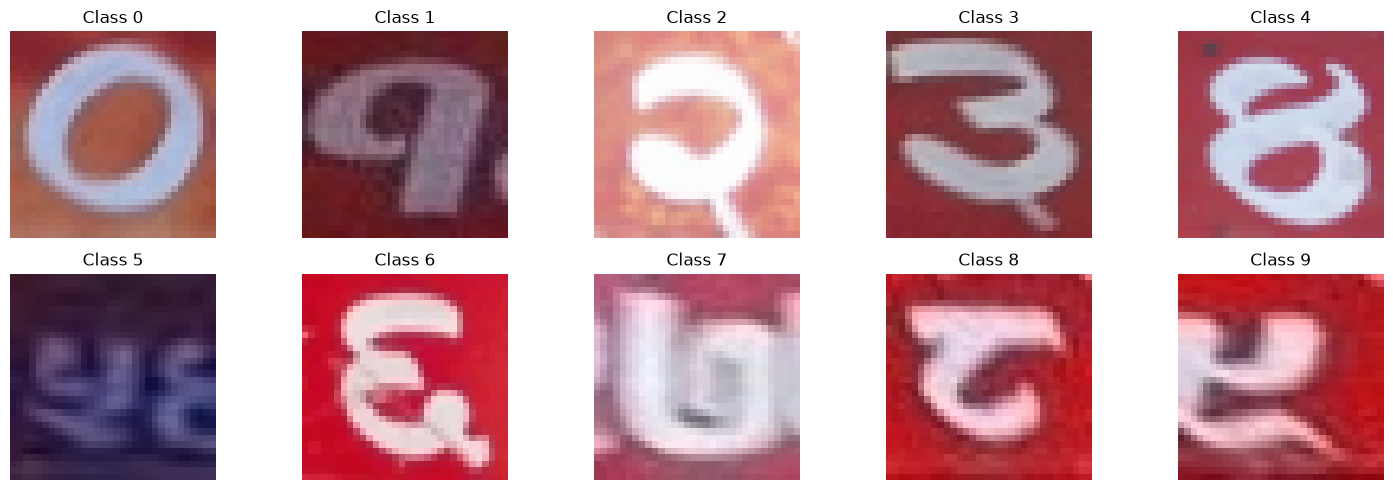

In [7]:
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    index = np.where(y == i)[0][0]
    plt.imshow(X[index])
    plt.title(f"Class {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Split dataset. 70& train, 15% validate, 15% test

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 1423
Validation images: 305
Testing images: 305


Build CNN model

In [9]:

def create_model(filters=32, dropout=0.3):

    model = Sequential([
        tf.keras.Input(shape=(32, 32, 3)),

        Conv2D(filters, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(filters * 2, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation="relu"),
        Dropout(dropout),

        Dense(len(class_names), activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

## Hyper parameter tuning
compare 2 cnn configs using different numbers of filters

In [10]:
results = []

for filters in [16, 32]:
    for dropout in [0.3, 0.5]:

        model = create_model(filters, dropout)

        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=5,
            batch_size=35,
            verbose=1
        )

        results.append({
            "filters": filters,
            "dropout": dropout,
            "val_accuracy": max(history.history["val_accuracy"])
        })

for result in results:
    print(result)

best_config = max(results, key=lambda x: x["val_accuracy"])

print("\nBest configuration:", best_config)

Epoch 1/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.1546 - loss: 2.4197 - val_accuracy: 0.3410 - val_loss: 2.2021
Epoch 2/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4167 - loss: 1.8642 - val_accuracy: 0.6590 - val_loss: 1.2941
Epoch 3/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6627 - loss: 1.1708 - val_accuracy: 0.8066 - val_loss: 0.8635
Epoch 4/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7498 - loss: 0.8416 - val_accuracy: 0.8361 - val_loss: 0.6971
Epoch 5/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8025 - loss: 0.6927 - val_accuracy: 0.8426 - val_loss: 0.6315
Epoch 1/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1279 - loss: 2.4506 - val_accuracy: 0.1836 - val_loss: 2.3397
Epoch 2/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2811 - loss: 2.1923 - val_accuracy: 0.6262 - val_loss: 1.8178
Epoch 3/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4989 - loss: 1.6532 - val_accuracy: 0.7508 - val_loss: 1

Train final model

In [11]:
final_model = create_model(
    best_config["filters"],
    best_config["dropout"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = final_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.1384 - loss: 2.4253 - val_accuracy: 0.4131 - val_loss: 2.2343
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3774 - loss: 1.9455 - val_accuracy: 0.6721 - val_loss: 1.3574
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5959 - loss: 1.3172 - val_accuracy: 0.7770 - val_loss: 0.9411
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6873 - loss: 1.0421 - val_accuracy: 0.8361 - val_loss: 0.6994
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7688 - loss: 0.8205 - val_accuracy: 0.8820 - val_loss: 0.5907
Epoch 6/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7716 - loss: 0.7520 - val_accuracy: 0.8820 - val_loss: 0.5191
Epoch 7/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8067 - loss: 0.6532 - val_accuracy: 0.8918 - val_loss: 0.4486
Epoch 8/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8299 - loss: 0.5949 - val_accuracy: 0.8787 - v

Evaluate the model

In [12]:
y_pred = np.argmax(final_model.predict(X_test), axis=1)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Macro Precision:",
      precision_score(y_test, y_pred, average="macro", zero_division=0))

print("Weighted Precision:",
      precision_score(y_test, y_pred, average="weighted", zero_division=0))

print("Macro Recall:",
      recall_score(y_test, y_pred, average="macro", zero_division=0))

print("Weighted Recall:",
      recall_score(y_test, y_pred, average="weighted", zero_division=0))

print("Macro F1-score:",
      f1_score(y_test, y_pred, average="macro", zero_division=0))

print("Weighted F1-score:",
      f1_score(y_test, y_pred, average="weighted", zero_division=0))

print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=class_names,
    zero_division=0
))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Accuracy: 0.9016393442622951
Macro Precision: 0.9137648298115669
Weighted Precision: 0.9062901122012056
Macro Recall: 0.9048875540991781
Weighted Recall: 0.9016393442622951
Macro F1-score: 0.9070192643723733
Weighted F1-score: 0.901472651415509

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        15
           1       0.92      0.92      0.92        25
           2       0.82      1.00      0.90        27
           3       0.88      0.82      0.85        28
           4       0.92      0.77      0.84        31
           5       0.90      0.97      0.93        29
           6       0.91      0.88      0.89        24
           7       0.95      0.91      0.93        22
           8       1.00      0.95      0.97        20
           9       1.00      0.89      0.94        18
          ba       0.81      0.94      0.87        31
          pa       0.91      0.89      0.

Confusion matrix

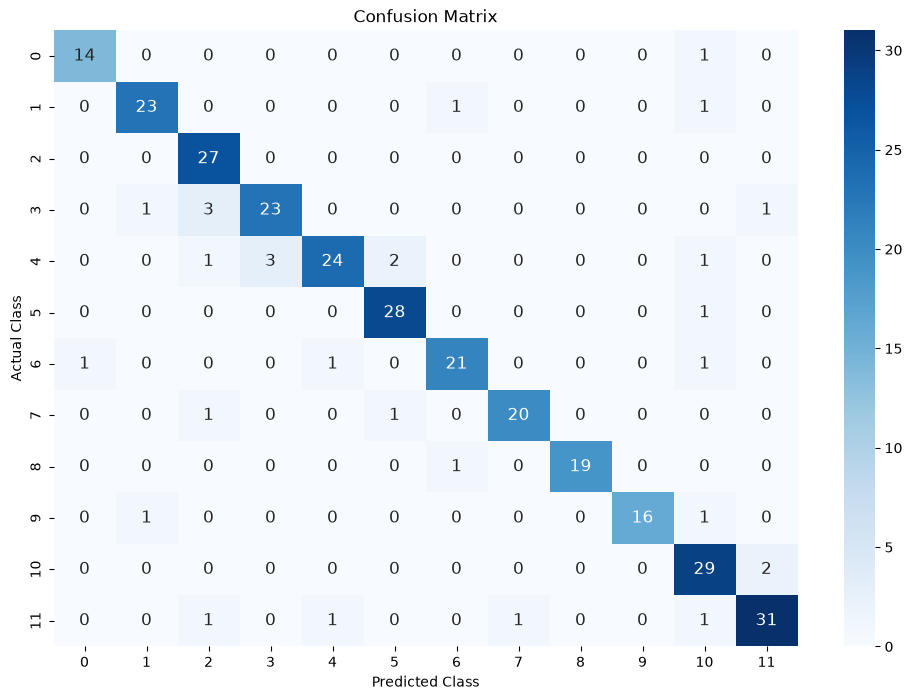

In [13]:
cm = confusion_matrix(
    y_test,
    y_pred,
    
    labels=np.arange(len(class_names))
)

plt.figure(figsize=(12, 8))

sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", annot_kws={"size": 12})

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

Plot training performance

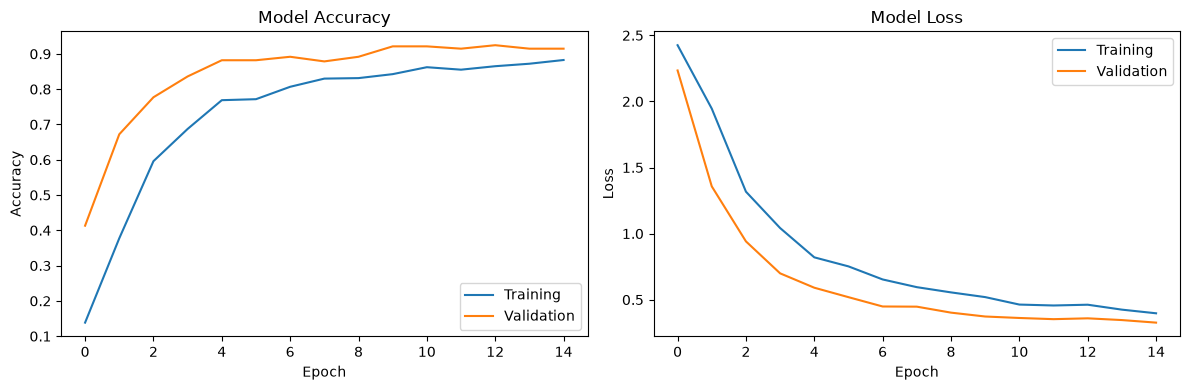

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## Summary

In [15]:
train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]
train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("Training Accuracy:", round(train_accuracy, 4))
print("Validation Accuracy:", round(val_accuracy, 4))
print("Training Loss:", round(train_loss, 4))
print("Validation Loss:", round(val_loss, 4))

if train_accuracy > val_accuracy + 0.1:
    print("Possible overfitting detected.")
elif val_loss > train_loss * 1.2:
    print("Possible overfitting: validation loss is higher.")
else:
    print("No strong overfitting signal from these final metrics.")

Training Accuracy: 0.8826
Validation Accuracy: 0.9148
Training Loss: 0.3972
Validation Loss: 0.3266
No strong overfitting signal from these final metrics.


## Model limitations
Image resolution: Resizing images to 32 × 32 pixels may remove important visual details. Dataset limitations: A small or imbalanced dataset may affect classification accuracy and generalization.
Model complexity: A simple CNN may not capture complex image features as effectively as more advanced architectures.
Hyperparameter tuning: Only four configurations are tested, so better configurations may exist.
Training limitations: The model may require more epochs or further tuning to achieve better performance.